In [2]:
import matplotlib as mtpy
print(mtpy.__version__)


3.10.7


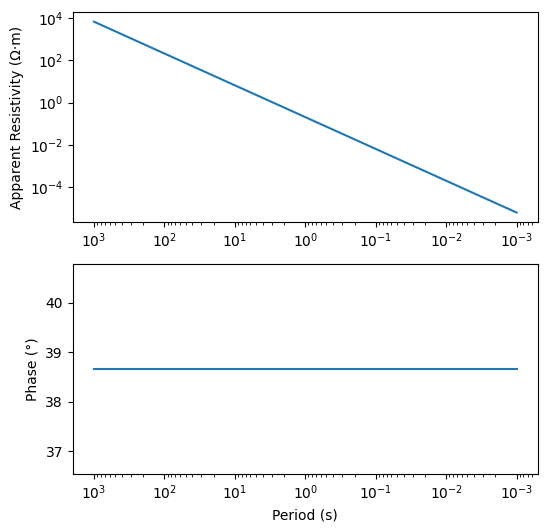

In [3]:
import numpy as np
import matplotlib.pyplot as plt

mu0 = 4 * np.pi * 1e-7

freq = np.logspace(-3, 3, 50)  ;

Z = (1e-3) * (1 + 1j * 0.8) * (freq**(-0.25));

rho_a = (np.abs(Z)**2) / (mu0 * 2 * np.pi * freq)

phase = np.rad2deg(np.arctan2(np.imag(Z), np.real(Z)))


# plotting section
fig, ax = plt.subplots(2, 1, figsize=(6,6))
ax[0].loglog(1/freq, rho_a)
ax[0].set_ylabel("Apparent Resistivity (Ω·m)")
ax[0].invert_xaxis()

ax[1].semilogx(1/freq, phase)
ax[1].set_xlabel("Period (s)")
ax[1].set_ylabel("Phase (°)")
ax[1].invert_xaxis()
plt.show()


In [5]:
!pip install mt_metadata

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/739.9 kB ? eta -:--:--
   ---------------------------------------- 739.9/739.9 kB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.0 MB 8.7 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/11.0 MB 7.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.0 MB 8.5 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.0 MB 7.9 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.0 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 7.9 MB/s  0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

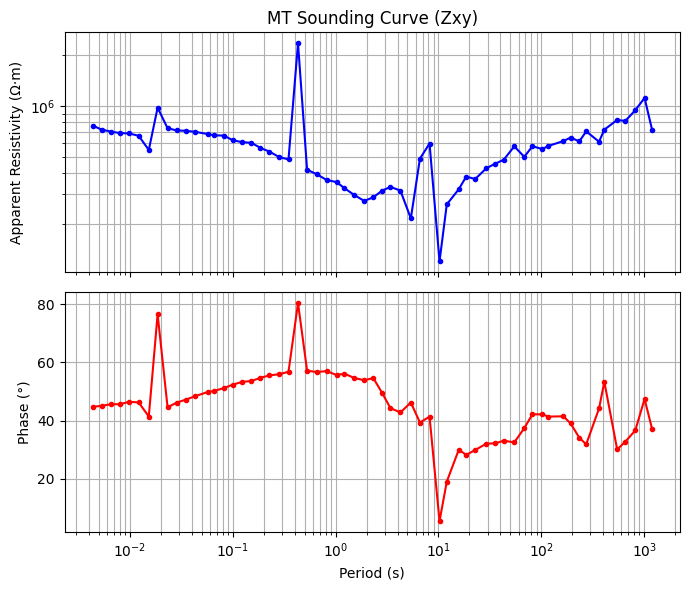

In [8]:
from mt_metadata.transfer_functions import TF
import numpy as np
import matplotlib.pyplot as plt

# Load your EDI file
edi_obj = TF()
edi_obj.read(fn="./BVV170923.edi")

# Access impedance data
freq = np.array(edi_obj.frequency)
# Get the Zxy component (off-diagonal)
Zxy = np.array(edi_obj.impedance.data[:, 0, 1])

# Compute apparent resistivity & phase for Zxy
mu0 = 4 * np.pi * 1e-7
# Calculate apparent resistivity from Zxy
rho_a = (1 / (mu0 * 2 * np.pi * freq)) * np.abs(Zxy)**2 
# Calculate phase from Zxy
phase = np.rad2deg(np.arctan2(np.imag(Zxy), np.real(Zxy)))

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# Plot Apparent Resistivity
ax[0].loglog(1/freq, rho_a, 'b.-')
ax[0].set_ylabel("Apparent Resistivity (Ω·m)")
ax[0].invert_xaxis()
ax[0].grid(True, which='both')
ax[0].set_title("MT Sounding Curve (Zxy)")

# Plot Phase
ax[1].semilogx(1/freq, phase, 'r.-')
ax[1].set_xlabel("Period (s)")
ax[1].set_ylabel("Phase (°)")
ax[1].invert_xaxis()
ax[1].grid(True, which='both')

plt.tight_layout()
plt.show()

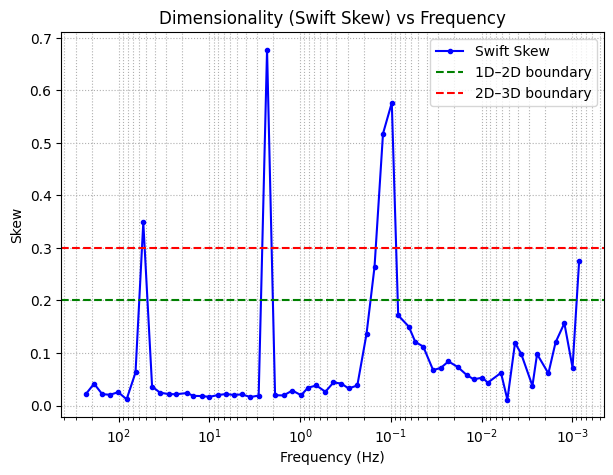

Interpretation guide:
  Skew < 0.2 → likely 1D (layered)
  0.2 ≤ Skew ≤ 0.3 → weak 2D features
  Skew > 0.3 → 3D or noisy site


In [14]:
from mt_metadata.transfer_functions import TF
import numpy as np
import matplotlib.pyplot as plt

# Load your EDI file
edi_obj = TF()
edi_obj.read(fn="./BVV170923.edi")

# --- Extract impedance tensor components ---
Zxx = np.array(edi_obj.impedance.data[:, 0, 0])
Zxy = np.array(edi_obj.impedance.data[:, 0, 1])
Zyx = np.array(edi_obj.impedance.data[:, 1, 0])
Zyy = np.array(edi_obj.impedance.data[:, 1, 1])
freq = np.array(edi_obj.frequency)

# --- Compute Swift Skew ---
# Formula: skew = |Zxx + Zyy| / |Zxy - Zyx|
skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)

# --- Plot Skew vs Frequency ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(freq, skew, 'b.-', label='Swift Skew')
ax.axhline(0.2, color='g', ls='--', label='1D–2D boundary')
ax.axhline(0.3, color='r', ls='--', label='2D–3D boundary')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Skew")
ax.set_title("Dimensionality (Swift Skew) vs Frequency")
ax.legend()
ax.grid(True, which='both', ls=':')
ax.invert_xaxis() # Puts high frequency (shallow) on the left
plt.show()

# --- Quick interpretation ---
print("Interpretation guide:")
print("  Skew < 0.2 → likely 1D (layered)")
print("  0.2 ≤ Skew ≤ 0.3 → weak 2D features")
print("  Skew > 0.3 → 3D or noisy site")